# ENSO from PaleoSST (R001) vs Cook 2024 reconstruction

Downloads realization R001 of the PaleoSST dataset  
(Samakinwa et al. 2021, *Sci. Data*; doi:10.1038/s41597-021-01043-1),  
extracts the NINO3.4 region (5°S–5°N, 170°W–120°W), computes an annual  
NINO3.4 index, and compares with the Cook 2024 reconstruction used in  
the famine dataset.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'pdf.fonttype':      42,
})

## 1. Download PaleoSST R001

In [2]:
URL       = 'https://ndownloader.figshare.com/files/27504296'  # R001
CACHE_DIR = '../data/paleosst_cache'
os.makedirs(CACHE_DIR, exist_ok=True)
nc_path   = os.path.join(CACHE_DIR, 'PaleoSST_R001.nc')

if not os.path.exists(nc_path):
    print('Downloading PaleoSST R001 (~1.3 GB)...')
    urllib.request.urlretrieve(URL, nc_path)
    print('Done.')
else:
    print('Cached:', nc_path)

Done.


## 2. Compute annual NINO3.4 index

NINO3.4 box: 5°S–5°N, 170°W–120°W → in 0–360° coords: 190°–240°

In [3]:
_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ds = xr.open_dataset(nc_path, decode_times=_coder)

# NINO3.4 box, lat-weighted spatial mean
box     = ds['sst'].sel(latitude=slice(5, -5), longitude=slice(190, 240))
weights = np.cos(np.deg2rad(box['latitude']))
nino_mon = box.weighted(weights).mean(dim=['latitude', 'longitude']).load()
ds.close()

# Annual mean, restrict to 1500–1800
nino_ann = (
    nino_mon.groupby('time.year').mean('time')
    .rename({'year': 'Year'})
    .to_series()
    .loc[1500:1800]
)

# 50-yr rolling detrend (same as famine dataset)
def detrend50(s):
    return s - s.rolling(50, min_periods=1, center=True).mean()

paleo_dt = detrend50(nino_ann)

print('PaleoSST R001 NINO3.4 (detrended):')
print(paleo_dt.describe())

PaleoSST R001 NINO3.4 (detrended):
count    301.000000
mean       0.000198
std        0.182782
min       -0.564649
25%       -0.122233
50%        0.001919
75%        0.119305
max        0.606484
Name: sst, dtype: float64


## 3. Load Cook 2024 NINO3.4 from famine data

In [4]:
famine = pd.read_csv('../processed data/famine_region_data.csv')
cook   = famine.groupby('Year')['nino34'].first().loc[1500:1800]
cook_dt = detrend50(cook)

# Align
df = pd.DataFrame({
    'PaleoSST': paleo_dt,
    'Cook2024': cook_dt,
}).dropna()

r, p = pearsonr(df['PaleoSST'], df['Cook2024'])
print(f'Pearson r = {r:.3f}, p = {p:.4g}, n = {len(df)}')

Pearson r = 0.043, p = 0.4566, n = 301


## 4. Figures

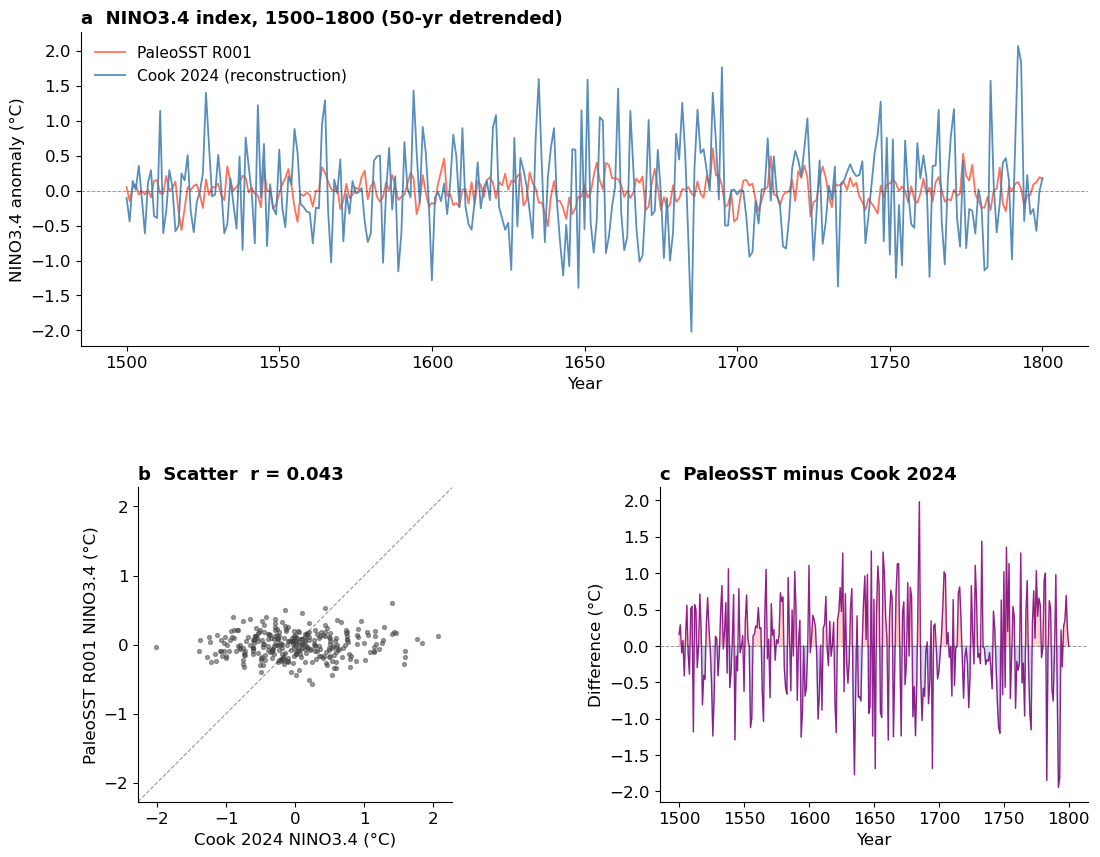

r = 0.043, p = 0.4566


In [5]:
fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel a: time series ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df['PaleoSST'], color='tomato',    lw=1.3, label='PaleoSST R001', alpha=0.9)
ax1.plot(df.index, df['Cook2024'], color='steelblue', lw=1.3, label='Cook 2024 (reconstruction)', alpha=0.9)
ax1.axhline(0, color='black', lw=0.7, ls='--', alpha=0.4)
ax1.set_xlabel('Year')
ax1.set_ylabel('NINO3.4 anomaly (°C)')
ax1.set_title('a  NINO3.4 index, 1500–1800 (50-yr detrended)',
              fontsize=13, fontweight='bold', loc='left')
ax1.legend(frameon=False, fontsize=11)

# ── Panel b: scatter ──────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(df['Cook2024'], df['PaleoSST'], s=8, alpha=0.5, color='#444444')
lim = max(df[['Cook2024', 'PaleoSST']].abs().max()) * 1.1
ax2.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, alpha=0.4)
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)
ax2.set_xlabel('Cook 2024 NINO3.4 (°C)')
ax2.set_ylabel('PaleoSST R001 NINO3.4 (°C)')
ax2.set_title(f'b  Scatter  r = {r:.3f}', fontsize=13, fontweight='bold', loc='left')
ax2.set_aspect('equal')

# ── Panel c: difference ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
diff = df['PaleoSST'] - df['Cook2024']
ax3.plot(df.index, diff, color='purple', lw=1.0, alpha=0.85)
ax3.axhline(0, color='black', lw=0.7, ls='--', alpha=0.4)
ax3.fill_between(df.index, diff, 0, where=(diff > 0), color='tomato',    alpha=0.25)
ax3.fill_between(df.index, diff, 0, where=(diff < 0), color='steelblue', alpha=0.25)
ax3.set_xlabel('Year')
ax3.set_ylabel('Difference (°C)')
ax3.set_title('c  PaleoSST minus Cook 2024', fontsize=13, fontweight='bold', loc='left')

out_dir = '../analysis/output/figures/extended data'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f'{out_dir}/figED_enso_paleosst_vs_cook.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f'r = {r:.3f}, p = {p:.4g}')